In [1]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [2]:
import zipfile

zip_path = "images.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")

Extracted successfully!


In [3]:
import os
os.listdir("/content/dataset")

['images']

In [ ]:
train_dir = "/content/dataset"

In [4]:
train_dir = "/content/dataset/images"

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

def create_model(optimizer):
    base_model = MobileNet(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    output = Dense(train_data.num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

optimizers = {
    "Adam": tf.keras.optimizers.Adam(0.001),
    "SGD": tf.keras.optimizers.SGD(0.001, momentum=0.9),
    "RMSprop": tf.keras.optimizers.RMSprop(0.001)
}

histories = {}
models = {}
epochs = 30

for name, opt in optimizers.items():
    print(f"\n🔥 Training with {name} optimizer...\n")

    model = create_model(opt)

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs
    )

    models[name] = model
    histories[name] = history

Found 9123 images belonging to 5 classes.
Found 2278 images belonging to 5 classes.

🔥 Training with Adam optimizer...

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 58s 151ms/step - accuracy: 0.8001 - loss: 0.5236 - val_accuracy: 0.8736 - val_loss: 0.3567
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.8959 - loss: 0.2839 - val_accuracy: 0.9034 - val_loss: 0.2734
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9309 - loss: 0.2021 - val_accuracy: 0.9416 - val_loss: 0.1865
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9516 - loss: 0.1458 - val_accuracy: 0.9315 - val_loss: 0.2007
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.9663 - loss: 0.1027 - val_accuracy: 0.9618 - val_loss: 0.1385
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.9781 - loss: 0.0731 - val_accuracy: 0.9680 - val_loss: 0.1219
Epoch 7/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms

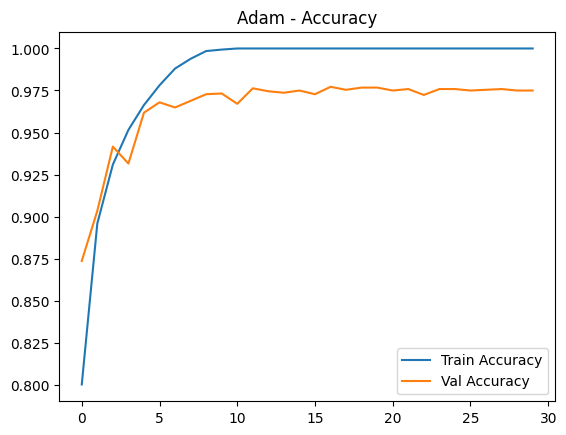

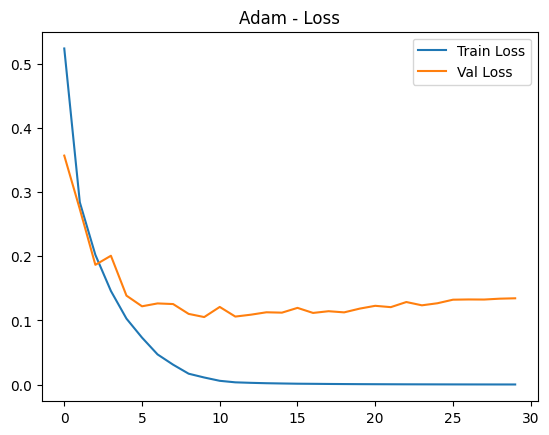

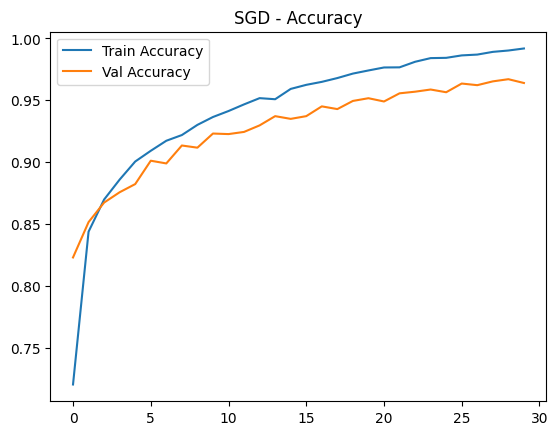

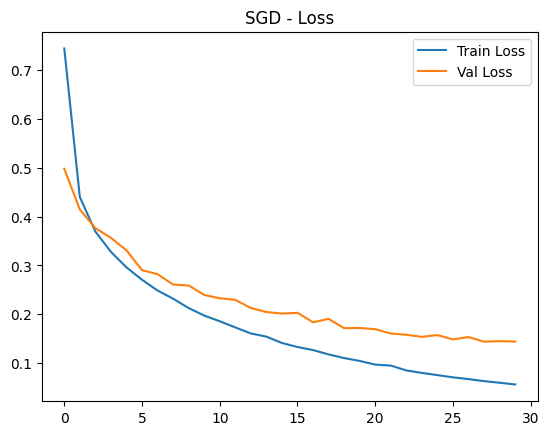

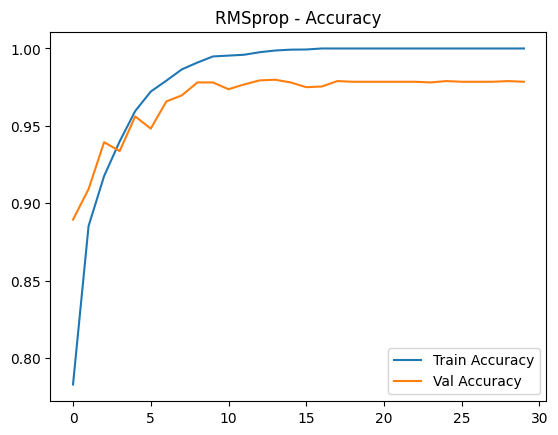

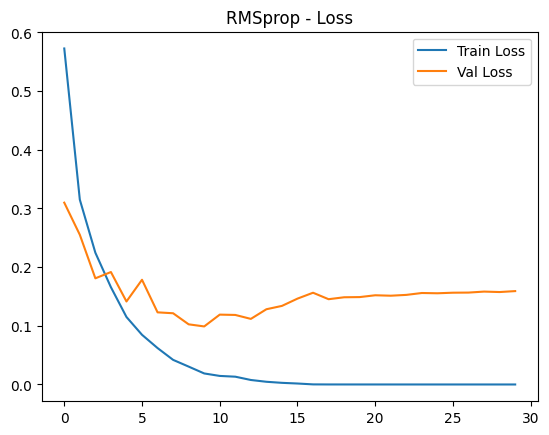

In [6]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

for name in histories:
    plot_history(histories[name], name)

In [7]:
summary = {}

for name, h in histories.items():
    summary[name] = {
        "Train Accuracy": h.history['accuracy'][-1],
        "Val Accuracy": h.history['val_accuracy'][-1],
        "Train Loss": h.history['loss'][-1],
        "Val Loss": h.history['val_loss'][-1]
    }

pd.DataFrame(summary).T

,Train Accuracy,Val Accuracy,Train Loss,Val Loss
Adam,1.000000,0.974978,0.000115,0.134398
SGD,0.991889,0.964004,0.056531,0.144286
RMSprop,1.000000,0.978490,0.000016,0.159160


In [8]:
results = {}

for name, model in models.items():
    loss, acc = model.evaluate(val_data)

    results[name] = {
        "Test Loss": loss,
        "Test Accuracy": acc
    }

pd.DataFrame(results).T

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9750 - loss: 0.1344
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9640 - loss: 0.1443
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9785 - loss: 0.1592


,Test Loss,Test Accuracy
Adam,0.134398,0.974978
SGD,0.144286,0.964004
RMSprop,0.159160,0.978490


In [9]:
model = models["Adam"]  # or any model

trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
total_params = model.count_params()

print("Trainable Parameters:", trainable_params)
print("Total Parameters:", total_params)

Trainable Parameters: 131845
Total Parameters: 3360709
